In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.models import mobilenet_v2

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "Blackheads",
    "Dark_Spots",
    "Inflammatory_Acne",
    "Normal",
    "Pigmentation",
    "Pores",
    "Redness",
    "Whiteheads",
    "Wrinkles"
]

model = mobilenet_v2(weights=None)

model.classifier[1] = nn.Linear(1280, len(CLASS_NAMES))

model.load_state_dict(
    torch.load(
        "../models/mobilenetv2_finetuned_best.pth",
        map_location=DEVICE
    )
)

model.to(DEVICE)
model.eval()

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
def predict_image(image_path, top_k=3):

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(output, dim=1)

        top_probs, top_indices = torch.topk(probabilities, k=top_k)

    print("=" * 55)
    print("Prediction Results")
    print("=" * 55)

    best_class = CLASS_NAMES[top_indices[0][0].item()]
    best_confidence = top_probs[0][0].item() * 100

    print(f"\n🏆 Best Prediction : {best_class}")
    print(f"🎯 Confidence      : {best_confidence:.2f}%")

    print("\nTop Predictions")
    print("-" * 55)

    for rank, (prob, idx) in enumerate(zip(top_probs[0], top_indices[0]), start=1):
        print(f"{rank}. {CLASS_NAMES[idx.item()]:20s} {prob.item()*100:6.2f}%")

    print("=" * 55)

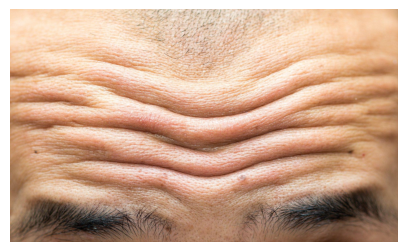

Prediction Results

🏆 Best Prediction : Wrinkles
🎯 Confidence      : 97.24%

Top Predictions
-------------------------------------------------------
1. Wrinkles              97.24%
2. Pores                  2.47%
3. Pigmentation           0.15%


In [6]:
predict_image(r"C:\Users\vnman\Downloads\t-9.jpeg")